# Python Clinic 3: Propositional Logic and Machine Learning

In this session, we're going to cover two topics:

1.  **Part 1: Propositional Logic with SymPy:** We'll explore how to represent and evaluate logical statements using Python library `SymPy`.
2.  **Part 2: Extension of Machine Learning:** We'll look at some linear algebra with NumPy and then introduce more `scikit-learn` functions which can help you to build, preprocess, and train several machine learning models.

## Part 1: Propositional Logic with SymPy

**What is Propositional Logic?**

It's the branch of logic that deals with propositions (statements that can be `True` or `False`) and the logical connectives that join them (like `AND`, `OR`, `NOT`, `IMPLIES`).

**Why SymPy?**

SymPy is a Python library for *symbolic mathematics*. It's perfect for defining logical symbols (like `P` and `Q`) and testing the properties of complex logical expressions.

In [1]:
# Import the tools we need from SymPy
from sympy import symbols, And, Not, Or, Implies, Equivalent
from sympy.logic.boolalg import truth_table
from sympy.logic.inference import satisfiable

### 1.1: Defining Symbols and Basic Operations

In logic, we use variables like `P` or `Q` to represent a statement (e.g., `P` = "It is raining"). We create these in SymPy using `symbols()`.

In [2]:
# Create two propositional symbols
P, Q = symbols('P Q')

print(f"Our symbols are: {P} and {Q}")

# Let's define the basic logical operations. 
# You can use the functions (e.g., And(P, Q)) or operators (e.g., P & Q)

# AND (P ∧ Q): True only if both P and Q are true
expr_and = And(P, Q)
print(f"AND expression: {expr_and}")

# OR (P ∨ Q): True if at least one of P or Q is true
expr_or = Or(P, Q)
print(f"OR expression: {expr_or}")

# NOT (¬P): Flips the truth value of P
expr_not = Not(P)
print(f"NOT expression: {expr_not}")

# IMPLIES (P → Q): "If P, then Q." Only false if P is true and Q is false.
expr_implies = Implies(P, Q)
print(f"IMPLIES expression: {expr_implies}")

# EQUIVALENT (P ↔ Q): "P if and only if Q." True if P and Q have the same truth value.
expr_equiv = Equivalent(P, Q)
print(f"EQUIVALENT expression: {expr_equiv}")

Our symbols are: P and Q
AND expression: P & Q
OR expression: P | Q
NOT expression: ~P
IMPLIES expression: Implies(P, Q)
EQUIVALENT expression: Equivalent(P, Q)


### 1.2: Truth Tables

A truth table is the classic way to evaluate a logical expression. It shows the final truth value for *every possible combination* of inputs.

A **tautology** is an expression that is *always* true, no matter the inputs. (e.g., `P ∨ ¬P`)
A **contradiction** is an expression that is *always* false. (e.g., `P ∧ ¬P`)

In [3]:
# Truth table for (P → Q)
expr1 = Implies(P, Q)
tt1 = list(truth_table(expr1, [P, Q])) # Output is a tuple of ((inputs), output), i.e., ((P_value, Q_value), result)
for row in tt1: # Iterate through each row of the truth table
    print(f"P={row[0][0]}, Q={row[0][1]}  =>  {row[1]}") # row[0] is the input tuple, row[1] is the output; row[0][0] is P's value, row[0][1] is Q's value

P=0, Q=0  =>  True
P=0, Q=1  =>  True
P=1, Q=0  =>  False
P=1, Q=1  =>  True


How to understand the truth table for (P → Q):

**(P → Q) is true in all cases except when P is true and Q is false.**

Consider if you promise, “If it rains (P), I'll bring an umbrella (Q),” the only way to break that promise is if it rains (P = true) but you don’t bring an umbrella (Q = false).
Other cases: 
- If it rains (P = true) and you bring an umbrella (Q = true) -> ture;
- If it does not rain (P = false), it does not matter if you bring an umbrella (Q = true) or not (Q = false)

In [4]:
# Tautology example: (P ∨ ¬P)
expr_tautology = Or(P, Not(P))
print(f"\nTruth table for: {expr_tautology}")
tt2 = list(truth_table(expr_tautology, [P]))
for row in tt2:
    print(f"P={row[0][0]}  =>  {row[1]}")


Truth table for: P | ~P
P=0  =>  True
P=1  =>  True


In [5]:
# Contradiction example: (P ∧ ¬P)
expr_contradiction = And(P, Not(P))
print(f"\nTruth table for: {expr_contradiction}")
tt3 = list(truth_table(expr_contradiction, [P]))
for row in tt3:
    print(f"P={row[0][0]}  =>  {row[1]}")


Truth table for: P & ~P
P=0  =>  False
P=1  =>  False


### 1.3: Satisfiability

Sometimes we don't need the *whole* truth table. We just want to know: **"Is there *at least one* assignment of inputs that makes this expression True?"**

This is called **satisfiability**. If an expression is satisfiable, `satisfiable()` will return a "model" (a dictionary of T/F assignments) that works. If it's a contradiction, it will return `False`.

In [6]:
# A simple satisfiable expression: P ∧ Q
expr_sat = And(P, Q)
model1 = satisfiable(expr_sat)
print(f"Is {expr_sat} satisfiable? {bool(model1)}")
print(f"A model that works: {model1}")

# A contradiction: P ∧ ¬P
expr_contra = And(P, Not(P))
model2 = satisfiable(expr_contra)
print(f"\nIs {expr_contra} satisfiable? {bool(model2)}")
print(f"A model that works: {model2}")

Is P & Q satisfiable? True
A model that works: {P: True, Q: True}

Is P & ~P satisfiable? False
A model that works: False


## Part 2: Machine Learning

### 2.1: The Linear Algebra Engine (NumPy)

Many ML models, especially Linear Regression, are solved using linear algebra. You might see the "normal equation" for linear regression as: $\theta = (X^T X)^{-1} X^T y$

Notice the $(...)^{-1}$? That's a **matrix inverse**. Let's look at `inv`, `det`, and `matrix_rank`.

* `det(A)`: The **determinant** of a matrix. If it's 0, the matrix is "singular" and **has no inverse**. This happens if your features are linearly dependent (e.g., you have the same feature twice). $det(A) = ad -bc$
* `inv(A)`: The **inverse** of a matrix. Only works if `det(A)` is not 0. $A \times A^{-1} = I$

$$
A = 
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\quad \Rightarrow \quad
A^{-1} = \frac{1}{ad - bc}
\begin{bmatrix}
d & -b \\
-c & a
\end{bmatrix}
$$
  
* `matrix_rank(A)`: The **rank** of a matrix. This tells you the number of linearly independent rows (or columns). If `rank(A)` is less than the number of columns, your features are linearly dependent.

In [7]:
import numpy as np
from numpy.linalg import inv, matrix_rank, det

# Let's create an invertible matrix (features are independent)
A = np.array([
    [1, 2],
    [3, 5]
])

print(f"Matrix A:\n{A}")
print(f"Determinant of A: {det(A):.1f}") # (1*5 - 2*3) = -1
print(f"Rank of A: {matrix_rank(A)}")
print(f"Inverse of A:\n{inv(A)}")

# Now, a singular matrix (features are dependent, col 2 = 2 * col 1)
B = np.array([
    [1, 2],
    [3, 6]
])

print(f"\nMatrix B:\n{B}")
print(f"Determinant of B: {det(B):.1f}") # (1*6 - 2*3) = 0
print(f"Rank of B: {matrix_rank(B)}")

try:
    if matrix_rank(B) < len(B):  # Rank less than number of rows/cols means singular
        raise np.linalg.LinAlgError("Singular matrix")
    print(inv(B))
except np.linalg.LinAlgError as e:
    print(f"Inverse of B: Error! {e}")

Matrix A:
[[1 2]
 [3 5]]
Determinant of A: -1.0
Rank of A: 2
Inverse of A:
[[-5.  2.]
 [ 3. -1.]]

Matrix B:
[[1 2]
 [3 6]]
Determinant of B: -0.0
Rank of B: 1
Inverse of B: Error! Singular matrix


### 2.2: Feature Preprocessing

Machine learning models are just math. They need *numbers* to work. What if our data is text (e.g., "Red", "Green", "Blue")? Or what if the relationship isn't a straight line? We have to *preprocess* our features.

#### OneHotEncoder
Used to convert **categorical features** into numerical ones. We *don't* want to say `Red=0`, `Green=1`, `Blue=2` because that implies an order (Blue > Green). Instead, we create "dummy variables":

* `Red` -> `[1, 0, 0]`
* `Green` -> `[0, 1, 0]`
* `Blue` -> `[0, 0, 1]`

In [8]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd # Pandas makes this easier to see

# Sample data with a categorical feature
data = {'color': ['Red', 'Green', 'Blue', 'Green', 'Red']}
df = pd.DataFrame(data)

print(f"Original Data:\n{df}")

encoder = OneHotEncoder(sparse_output=False) # sparse=False gives a readable numpy array
encoded_features = encoder.fit_transform(df[['color']])

print(f"\nEncoded Features:\n{encoded_features}")

Original Data:
   color
0    Red
1  Green
2   Blue
3  Green
4    Red

Encoded Features:
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


#### PolynomialFeatures
Used to create **interaction terms** and **polynomial terms**. This lets a simple linear model learn *non-linear* relationships (like $y = x^2 + ...$).

If you have features `[a, b]`, `PolynomialFeatures(degree=2)` will create: `[1, a, b, a^2, ab, b^2]`.

In [17]:
from sklearn.preprocessing import PolynomialFeatures

X = np.array([
    [2, 3], # Sample 1
    [4, 5]  # Sample 2
])

print(f"Original X (features a, b):\n{X}")

poly = PolynomialFeatures(degree=2) # include the '1'
# poly = PolynomialFeatures(degree=2, include_bias=False) # include_bias=False skips the '1'
X_poly = poly.fit_transform(X)

print(f"\nPolynomial X:\n{X_poly}")
print(f"Feature names: {poly.get_feature_names_out(['a', 'b'])}")

Original X (features a, b):
[[2 3]
 [4 5]]

Polynomial X:
[[ 1.  2.  3.  4.  6.  9.]
 [ 1.  4.  5. 16. 20. 25.]]
Feature names: ['1' 'a' 'b' 'a^2' 'a b' 'b^2']


### 2.3: Supervised Learning Models

In supervised learning, we have data `X` and labels `y`. The model learns the mapping from `X` to `y`.

#### Ridge Regression (vs. Linear Regression)

* **Linear Regression:** Tries to find the *single best line* that fits the data. It's vulnerable to **overfitting** (being too specific to the training data).
* **Ridge Regression:** This is a *regularized* model. It adds a "penalty" (called L2 regularization) that *shrinks* the coefficients. This makes the model less complex, more robust to collinear features, and less prone to overfitting.

**Analogy:** Linear Regression is a student who memorizes the *exact* practice questions. Ridge Regression is a student who tries to learn the *general concepts*.

#### Polynomial Regression with Ridge (L2 Regularization)

When we fit polynomial features, the model can become *extremely complex* and overfit easily. Ridge regularization becomes even more critical here.

**The Problem:**
* Polynomial regression: $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + ... + \beta_d x^d$
* High-degree polynomials create many correlated features (x, x², x³, ...)
* Coefficients can become extremely large → wild oscillations → overfitting

**The Solution:**

**Standard Polynomial Loss (Linear Regression):**
$$\text{Loss} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Ridge Polynomial Loss (with L2 penalty):**
$$\text{Loss} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{d} \beta_j^2$$

**What Ridge Does:**
* The penalty term $\alpha \sum \beta_j^2$ shrinks large coefficients
* Higher $\alpha$ → more regularization → smoother curves
* Prevents wild oscillations even with high polynomial degrees

**Example:**
- Degree 9 polynomial without Ridge: coefficients = [120, -450, 830, ...]
- Degree 9 polynomial with Ridge: coefficients = [2.5, -3.1, 1.8, ...]

**Result:** Ridge keeps high-degree polynomial models stable and prevents overfitting while maintaining flexibility.

In [10]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Create overfitting scenario: few samples, many features, high noise
X, y, coef = make_regression(n_samples=50, n_features=40, n_informative=5, 
                              noise=50, coef=True, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Compare Linear Regression vs Ridge
lr = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=10.0).fit(X_train, y_train)

print("Model              Train MSE    Test MSE")
print(f"Linear Regression  {mean_squared_error(y_train, lr.predict(X_train)):8.2f}    {mean_squared_error(y_test, lr.predict(X_test)):8.2f}")
print(f"Ridge (alpha=10)   {mean_squared_error(y_train, ridge.predict(X_train)):8.2f}    {mean_squared_error(y_test, ridge.predict(X_test)):8.2f}")

# Effect of alpha
print("\nAlpha    Test MSE")
for alpha in [0.1, 1.0, 10.0, 100.0]:
    ridge_temp = Ridge(alpha=alpha).fit(X_train, y_train)
    print(f"{alpha:5.1f}    {mean_squared_error(y_test, ridge_temp.predict(X_test)):8.2f}")

Model              Train MSE    Test MSE
Linear Regression      0.00    24207.35
Ridge (alpha=10)    1022.45     4078.71

Alpha    Test MSE
  0.1    17786.53
  1.0     7203.81
 10.0     4078.71
100.0     6109.83


Alpha = regularization strength

↑ Increase alpha → Smaller coefficients → Less overfitting → Better generalization

↑↑ Too high alpha → Coefficients too small → Underfitting → Poor performance

#### MLPClassifier (Neural Network)

**MLP** stands for **Multi-Layer Perceptron**. This is usually your first neural network! 

It's a **classifier** that can learn highly **non-linear** patterns. It's made of an input layer, one or more *hidden layers*, and an output layer. It's great for problems where a straight line (like linear regression) just won't work. Can capture complex and non-linear relationships.


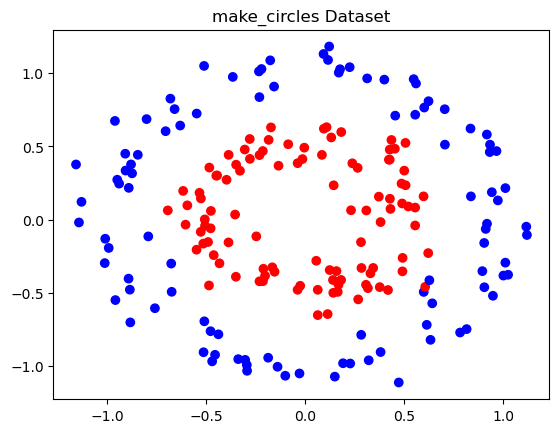


MLP Classifier Score: 99.50%


In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_circles # A classic non-linear problem
import matplotlib.pyplot as plt

# Create the dataset
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

# Plot it - see? You can't draw one line to separate these.
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='bwr')
plt.title("make_circles Dataset")
plt.show()

# Create and train the MLP
# hidden_layer_sizes=(10, 5) means 2 hidden layers: one with 10 neurons, one with 5
mlp = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=5000, random_state=42)
mlp.fit(X_circles, y_circles)

# 4. Check accuracy
mlp_score = mlp.score(X_circles, y_circles)
print(f"\nMLP Classifier Score: {mlp_score*100:.2f}%")

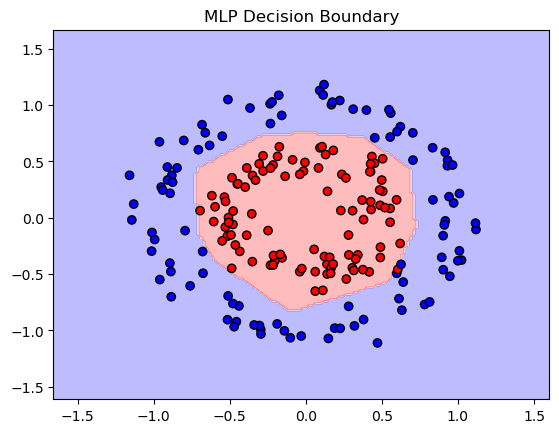

In [12]:
# Visualize decision boundary
h = 0.02
x_min, x_max = X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5
y_min, y_max = X_circles[:, 1].min() - 0.5, X_circles[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='bwr', edgecolors='k')
plt.title("MLP Decision Boundary")
plt.show()

### 2.4: Unsupervised Learning

What if we **don't have labels** (`y`)? In unsupervised learning, the goal is to find hidden structure in the data `X` itself.

#### KMeans (Clustering) in sklearn

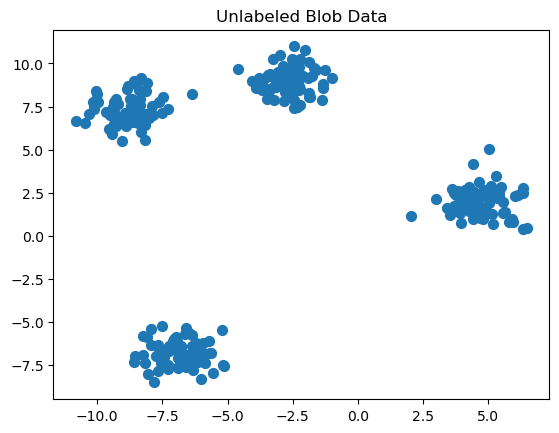

In [13]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Create data with 4 'blobs' (clusters)
X_blobs, y_true_blobs = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Plot the raw, unlabeled data (imagine we don't know the colors)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=50)
plt.title("Unlabeled Blob Data")
plt.show()



d:\Anaconda\envs\EE2213\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


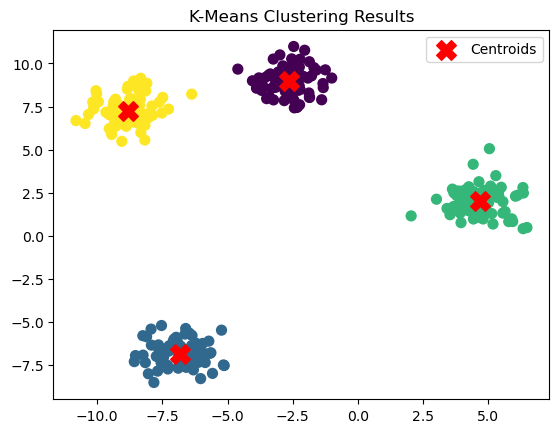

In [18]:
# Create and train the KMeans model
# We have to tell it n_clusters=4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_blobs)

# Get the cluster and the centers
y_pred_kmeans = kmeans.predict(X_blobs)
centers = kmeans.cluster_centers_

plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_pred_kmeans, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title("K-Means Clustering Results")
plt.legend()
plt.show()

## For the following libraries, please check our previous sessions

In [15]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
import matplotlib.pyplot as plt